In [1]:
!pip install -q plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
print('All libraries imported!')

All libraries imported!


In [6]:
uploaded = files.upload()
if not uploaded:
    raise ValueError("No file was uploaded. Please click 'Choose Files', select personal_finance.csv, and rerun this cell.")
filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

Saving personal_transactions.csv to personal_transactions.csv
Uploaded: personal_transactions.csv


In [7]:
df = pd.read_csv(filename)

print(f'Shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (806, 6)

Column names: ['Date', 'Description', 'Amount', 'Transaction Type', 'Category', 'Account Name']

Data types:
Date                 object
Description          object
Amount              float64
Transaction Type     object
Category             object
Account Name         object
dtype: object

First 5 rows:


,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card


In [10]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
print(df.columns)

Index(['date', 'description', 'amount', 'transaction_type', 'category',
       'account_name'],
      dtype='object')


In [11]:
def detect_column(columns, patterns, logical_name):
    matches = [c for c in columns if any(pattern in c for pattern in patterns)]
    if not matches:
        available_columns = ', '.join(map(str, columns))
        expected_patterns = ', '.join(patterns)
        raise ValueError(
            f"Could not auto-detect the {logical_name} column. "
            f"Expected a column containing one of: {expected_patterns}. "
            f"Available columns: {available_columns}"
        )
    return matches[0]

date_col     = detect_column(df.columns, ['date'], 'date')
category_col = detect_column(df.columns, ['categor'], 'category')
amount_col   = detect_column(df.columns, ['amount', 'spend', 'value'], 'amount')

print(f'Date column     : {date_col}')
print(f'Category column : {category_col}')
print(f'Amount column   : {amount_col}')

# Parse dates and extract month/year
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['year_month'] = df[date_col].dt.to_period('M')

# Make sure amounts are positive numbers
df[amount_col] = df[amount_col].abs()

Date column     : date
Category column : category
Amount column   : amount


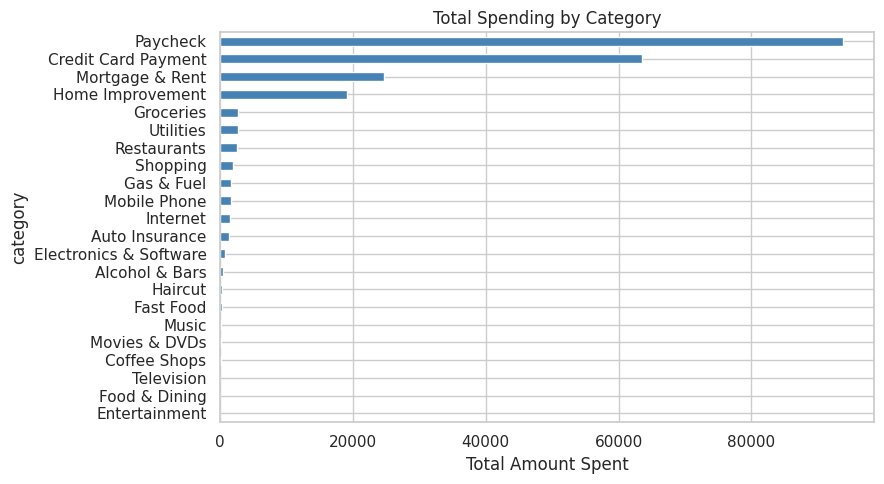

In [12]:
category_totals = (
    df.groupby(category_col)[amount_col]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
category_totals.plot(kind='barh', color='steelblue')
plt.title('Total Spending by Category')
plt.xlabel('Total Amount Spent')
plt.tight_layout()
plt.show()

In [13]:
monthly_totals = (
    df.groupby('year_month')[amount_col]
    .sum()
    .reset_index()
)
monthly_totals['year_month'] = monthly_totals['year_month'].astype(str)   # Convert Period to string for Plotly

fig = px.line(
    monthly_totals,
    x='year_month',
    y=amount_col,
    markers=True,
    title='Monthly Total Spending Over Time',
    labels={amount_col: 'Total Spent', 'year_month': 'Month'},
    template='plotly_white'
)
fig.show()

In [14]:
feature_matrix = df.pivot_table(
    index='year_month',
    columns=category_col,
    values=amount_col,
    aggfunc='sum',
    fill_value=0
)

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'(rows = months, columns = spending categories)')
print(f'\nCategories: {list(feature_matrix.columns)}')
feature_matrix.head()

Feature matrix shape: (21, 22)
(rows = months, columns = spending categories)

Categories: ['Alcohol & Bars', 'Auto Insurance', 'Coffee Shops', 'Credit Card Payment', 'Electronics & Software', 'Entertainment', 'Fast Food', 'Food & Dining', 'Gas & Fuel', 'Groceries', 'Haircut', 'Home Improvement', 'Internet', 'Mobile Phone', 'Mortgage & Rent', 'Movies & DVDs', 'Music', 'Paycheck', 'Restaurants', 'Shopping', 'Television', 'Utilities']


category,Alcohol & Bars,Auto Insurance,Coffee Shops,Credit Card Payment,Electronics & Software,Entertainment,Fast Food,Food & Dining,Gas & Fuel,Groceries,...,Internet,Mobile Phone,Mortgage & Rent,Movies & DVDs,Music,Paycheck,Restaurants,Shopping,Television,Utilities
year_month,,,,,,,,,,,,,,,,,,,,,
2018-01,0.00,0.0,3.0,4027.69,0.0,0.00,32.91,0.0,65.29,87.73,...,69.99,89.46,1247.44,11.76,10.69,4000.0,156.80,100.37,0.0,140.0
2018-02,14.00,0.0,6.0,2296.36,0.0,0.00,10.66,0.0,68.68,63.74,...,74.99,89.52,1247.44,11.76,10.69,4000.0,290.85,11.11,0.0,160.0
2018-03,19.50,0.0,10.0,2643.00,0.0,0.00,23.34,0.0,65.45,171.07,...,74.99,89.52,1247.44,11.76,10.69,6000.0,234.05,73.85,0.0,147.0
2018-04,0.00,75.0,7.0,6333.76,0.0,0.00,0.00,0.0,81.56,274.39,...,74.99,89.52,1247.44,18.17,10.69,4000.0,202.27,54.47,0.0,125.0
2018-05,27.77,75.0,0.0,1976.02,0.0,9.62,27.79,0.0,72.74,289.21,...,74.99,111.18,1247.44,38.01,10.69,4000.0,127.30,219.45,0.0,125.0


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

print(f'Scaled feature matrix shape: {X_scaled.shape}')

Scaled feature matrix shape: (21, 22)


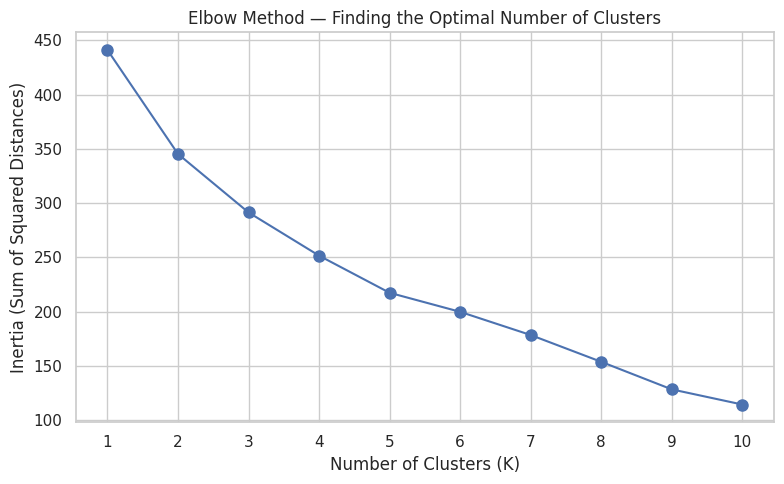

Look for the "elbow" — the K value where the curve starts to flatten out.
That is your ideal number of clusters.


In [16]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method — Finding the Optimal Number of Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()
print('Look for the "elbow" — the K value where the curve starts to flatten out.')
print('That is your ideal number of clusters.')

In [17]:
CHOSEN_K = 3

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

print(f'K-Means trained with K={CHOSEN_K}')
print(f'Final inertia: {kmeans.inertia_:.2f}')

K-Means trained with K=3
Final inertia: 291.41


In [18]:
feature_matrix['cluster'] = kmeans.labels_

print('Cluster assignments:')
print(feature_matrix['cluster'].value_counts().sort_index())
print(f'\nMonths per cluster (out of {len(feature_matrix)} total months)')

Cluster assignments:
cluster
0    9
1    9
2    3
Name: count, dtype: int64

Months per cluster (out of 21 total months)


In [19]:
category_cols = [c for c in feature_matrix.columns if c != 'cluster']
cluster_profiles = feature_matrix.groupby('cluster')[category_cols].mean()

print('=== Average Spending Per Category Per Cluster ===')
print(cluster_profiles.round(2).to_string())
print('\nLook at which cluster has the highest values in each column.')
print('Try to label each cluster with a description like:')
print('  Cluster 0: "Frugal month"  |  Cluster 1: "High food & entertainment"  |  Cluster 2: "Big spending month"')

=== Average Spending Per Category Per Cluster ===
category  Alcohol & Bars  Auto Insurance  Coffee Shops  Credit Card Payment  Electronics & Software  Entertainment  Fast Food  Food & Dining  Gas & Fuel  Groceries  Haircut  Home Improvement  Internet  Mobile Phone  Mortgage & Rent  Movies & DVDs  Music  Paycheck  Restaurants  Shopping  Television  Utilities
cluster                                                                                                                                                                                                                                                                                                              
0                  28.00            75.0          7.23              3387.91                   79.89           0.00        0.0           0.00       68.81     108.01    18.78           1115.43     75.00         65.00          1100.00           0.00  10.69   4638.89       108.77     61.64       11.64     132.67
1                  2

In [20]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)    # Reduce to 2 dimensions

pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'Cluster': feature_matrix['cluster'].astype(str),
    'Month': feature_matrix.index.astype(str)
})

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    hover_data=['Month'],
    title='Spending Clusters Visualized with PCA (2D)',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
    template='plotly_white',
    size_max=12
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()

variance_explained = pca.explained_variance_ratio_.sum() * 100
print(f'\nVariance explained by 2 components: {variance_explained:.1f}%')
print('If clusters are well-separated in the chart, K-Means found distinct groups!')


Variance explained by 2 components: 40.2%
If clusters are well-separated in the chart, K-Means found distinct groups!


In [21]:
cluster_long = cluster_profiles.reset_index().melt(
    id_vars='cluster',
    var_name='Category',
    value_name='Average Spending'
)
cluster_long['cluster'] = 'Cluster ' + cluster_long['cluster'].astype(str)

fig = px.bar(
    cluster_long,
    x='Category',
    y='Average Spending',
    color='cluster',
    barmode='group',
    title='Average Spending per Category by Cluster',
    template='plotly_white'
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()
print('Each cluster group of bars shows the average spending for that category per cluster.')

Each cluster group of bars shows the average spending for that category per cluster.
